In [3]:
from src import data_loader, features, volatility, regimes, models_xgb

# 1. Ingest & Transform
raw_df = data_loader.fetch_raw_data()
stat_df = features.engineer_stationary_features(raw_df)
garch_df = volatility.generate_expanding_garch(stat_df)

# 2. HMM Target Generation (Now immune to Label Switching)
hmm_df = regimes.generate_expanding_hmm_targets(
    garch_df,
    min_window=504,
    feature_cols=['Log_Return', 'Vol_EGARCH'], 
    vol_col='Vol_EGARCH',
    n_components=3
)

# 3. Merge & Lag
master_df = garch_df.join(hmm_df, how='inner')
cols_to_lag = [
    'Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
    'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff'
]
final_df = features.create_lags(master_df, feature_cols=cols_to_lag)

# 4. Train & Evaluate
final_model, feature_names = models_xgb.train_xgb_walk_forward(
    df=final_df, 
    target_col='Target_HMM', 
    n_splits=4,
    use_mlflow=False # Set to True once you `pip install mlflow`
)

2026-06-04 10:30:18 - src.data_loader - INFO - Loading cached master raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...


2026-06-04 10:30:18 - src.features - INFO - Engineering stationary features and applying macro lags...


2026-06-04 10:30:18 - src.features - INFO - Stationary transformation complete. Final shape: (6469, 8)


2026-06-04 10:30:18 - src.volatility - INFO - Generating Expanding GARCH & EGARCH (Window: 252, Refit: 21 days)...


2026-06-04 10:30:30 - src.volatility - INFO - Out-of-sample generation complete. Shape: (6217, 10)


...

2026-06-04 10:32:41 - src.models_xgb - INFO - Fold 4 Results -> Accuracy: 0.8224 | Log Loss: 0.5541


2026-06-04 10:32:41 - src.models_xgb - INFO - ============================================================


2026-06-04 10:32:41 - src.models_xgb - INFO - AGGREGATED WALK-FORWARD PERFORMANCE


2026-06-04 10:32:41 - src.models_xgb - INFO - ============================================================


                    precision    recall  f1-score   support

    Class 0 (Calm)       0.72      0.92      0.81      2310
Class 1 (Elevated)       0.74      0.54      0.62      1509
   Class 2 (Shock)       0.77      0.54      0.64       744

          accuracy                           0.73      4563
         macro avg       0.74      0.67      0.69      4563
      weighted avg       0.74      0.73      0.72      4563



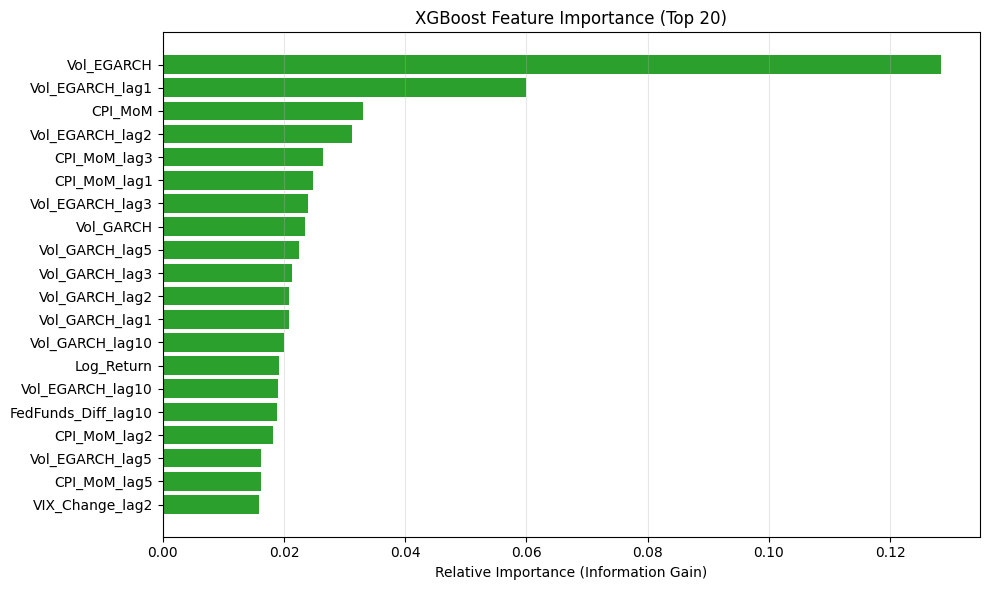

In [4]:
# 5. Visualize
models_xgb.plot_feature_importance(final_model, feature_names)